# Clasificación Multiclase de Sonidos con Machine Learning
## Dataset: UrbanSound8K

> 🔗 **Fuente del dataset:** [Kaggle – UrbanSound8K](https://www.kaggle.com/datasets/chrisfilo/urbansound8k)

Este cuadernillo implementa un sistema completo de clasificación de sonidos ambientales urbanos.  
Se combina el procesamiento de señales de audio (extracción de MFCC) con un modelo de **Regresión Logística Multiclase** entrenado mediante el enfoque **One-vs-All (OvA)**, optimizado con `scipy.optimize`.

---

### 🗂️ Clases del Dataset UrbanSound8K

El dataset contiene **8,732 clips de audio** etiquetados en **10 categorías** de sonidos urbanos:

| `classID` | Clase             | Descripción                              |
|:---------:|:------------------|:-----------------------------------------|
| 0         | `air_conditioner` | Aire acondicionado                       |
| 1         | `car_horn`        | Bocina de automóvil                      |
| 2         | `children_playing`| Niños jugando                            |
| 3         | `dog_bark`        | Ladrido de perro                         |
| 4         | `drilling`        | Taladro / perforación                    |
| 5         | `engine_idling`   | Motor en ralentí                         |
| 6         | `gun_shot`        | Disparo de arma                          |
| 7         | `jackhammer`      | Martillo neumático                       |
| 8         | `siren`           | Sirena de emergencia                     |
| 9         | `street_music`    | Música callejera                         |

Cada audio tiene una duración máxima de **4 segundos** y está almacenado en 10 *folds* predefinidos para validación cruzada.

---


## 1. Importación de Librerías

A continuación se importan todas las bibliotecas necesarias para el proyecto:

- **`pandas` / `numpy`**: Manipulación de datos y operaciones matriciales.
- **`librosa`**: Procesamiento de señales de audio y extracción de características.
- **`scipy.optimize`**: Algoritmos de optimización numérica (L-BFGS-B).
- **`sklearn`**: Utilidades para dividir datos, normalizar y medir accuracy.
- **`matplotlib`**: Visualización de resultados.


In [1]:
import pandas as pd
import numpy as np
import os
import librosa

import sounddevice as sd
import soundfile as sf
import matplotlib.pyplot as plt


from matplotlib import pyplot
from scipy import optimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


---

## 2. Carga y Preparación del Dataset

### ¿Qué contiene el archivo CSV?

El archivo `UrbanSound8K.csv` es el **metadato** del dataset: no contiene los audios directamente,  
sino una tabla con información de cada clip:

| Columna           | Descripción                                         |
|:------------------|:----------------------------------------------------|
| `slice_file_name` | Nombre del archivo de audio (`.wav`)                |
| `fold`            | Número de carpeta (1–10) donde se almacena el audio |
| `classID`         | Identificador numérico de la clase (0–9)            |
| `class`           | Nombre textual de la clase                          |

La ruta completa a cada archivo se construye como: `DATA_PATH/fold{N}/{slice_file_name}`


In [2]:
df = pd.read_csv("D:/Universidad/5to Semestre/Inteligencia Artificial/Datasets/multimodal/archive/UrbanSound8K.csv")
df.head()


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [3]:
# Ruta base donde se encuentran las carpetas fold1, fold2, ..., fold10
DATA_PATH = "D:/Universidad/5to Semestre/Inteligencia Artificial/Datasets/multimodal/archive"

def get_file_path(row):
    # Construye la ruta completa: DATA_PATH/fold{N}/nombre_archivo.wav
    return os.path.join(DATA_PATH, f"fold{row['fold']}", row['slice_file_name'])

# Aplica la función fila por fila para crear la columna 'file_path'
df["file_path"] = df.apply(get_file_path, axis=1)


---

## 3. Extracción de Características: MFCC

### ¿Qué son los coeficientes MFCC?

Los **Mel-Frequency Cepstral Coefficients (MFCC)** son una representación compacta del espectro de potencia de una señal de audio.  
Imitan la percepción auditiva humana mediante una escala de frecuencias no lineal (escala Mel).

El proceso de cálculo es:

1. **Ventaneo:** Se divide el audio en tramas cortas solapadas (~25 ms).
2. **FFT:** Se calcula la Transformada de Fourier de cada trama.
3. **Banco de filtros Mel:** Se aplica un banco de filtros triangulares en escala Mel para comprimir el espectro.
4. **Logaritmo:** Se aplica el logaritmo para representar la energía perceptivamente.
5. **DCT:** Se aplica la Transformada Coseno Discreta para decorrelacionar los coeficientes.

El resultado es una **matriz 2D** de forma `(n_mfcc, T)` donde `n_mfcc` son los coeficientes por trama y `T` el número de tramas temporales.

### Características adicionales: Delta y Delta-Delta

Para capturar la **dinámica temporal** del audio, se calculan:

- **Delta (Δ):** Derivada de primer orden de los MFCC → velocidad de cambio espectral.
- **Delta-Delta (ΔΔ):** Derivada de segundo orden → aceleración del cambio espectral.

Finalmente, se toma la **media temporal** de cada coeficiente, produciendo un vector fijo de:

$$\text{Vector final} = \underbrace{40}_{\text{MFCC}} + \underbrace{40}_{\Delta} + \underbrace{40}_{\Delta\Delta} = \mathbf{120 \text{ características}}$$


In [27]:
def extract_features(file_path):
    try:
        # Carga el archivo de audio; 'kaiser_fast' usa un resampler rápido
        # Retorna: audio (señal 1D en float32) y sr (tasa de muestreo, ej. 22050 Hz)
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')

        # Descarta audios completamente vacíos o corruptos
        if len(audio) == 0:
            return None

        # Calcula los MFCC: matriz de forma (40, T)
        # n_mfcc=40 → número de coeficientes cepstrales a extraer
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Descarta audios demasiado cortos (menos de 9 tramas temporales)
        # ya que el cálculo de delta requiere un mínimo de ventana
        if mfcc.shape[1] < 9:
            return None

        # Delta de primer orden: captura la velocidad de cambio de los MFCC
        delta = librosa.feature.delta(mfcc)

        # Delta de segundo orden: captura la aceleración del cambio espectral
        delta2 = librosa.feature.delta(mfcc, order=2)

        # Promedia sobre el eje temporal (axis=1) → vector de 40 valores por coeficiente
        mfcc_mean   = np.mean(mfcc,   axis=1)   # (40,)
        delta_mean  = np.mean(delta,  axis=1)   # (40,)
        delta2_mean = np.mean(delta2, axis=1)   # (40,)

        # Concatena horizontalmente los tres vectores → vector final de 120 características
        return np.hstack([mfcc_mean, delta_mean, delta2_mean])  # (120,)

    except Exception as e:
        # Informa del error sin detener el proceso completo
        print("Error en:", file_path)
        print(e)
        return None


### Extracción sobre todo el Dataset

Se itera sobre cada fila del DataFrame y se extrae el vector de características del audio correspondiente.  
Los archivos corruptos o inválidos se omiten y se cuentan por separado.


In [29]:
features = []   # Almacena los vectores de características
labels   = []   # Almacena el classID correspondiente
errores  = 0    # Contador de archivos problemáticos

# Diccionario para rastrear cuántos ejemplos llevamos por clase
conteo_clases = {}

print("Extrayendo características... por favor espera.")

for index, row in df.iterrows():
    data = extract_features(row["file_path"])
    label = row["classID"]
    
    if data is not None:
        features.append(data)
        labels.append(label)
        
        # Actualizar el conteo por clase
        conteo_clases[label] = conteo_clases.get(label, 0) + 1
    else:
        errores += 1

# Convertir a arrays de numpy al finalizar
X = np.array(features)
y = np.array(labels)

# --- REPORTE DE EXTRACCIÓN ---
print("-" * 30)
print(f"PROCESO FINALIZADO")
print(f"Total de archivos procesados con éxito: {len(labels)}")
print(f"Total de errores: {errores}")
print("-" * 30)
print("DISTRIBUCIÓN POR CLASE:")

# Nombres de las clases para que el reporte sea legible
class_names_list = [
    'air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling',
    'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music'
]

# Mostrar cuántos hay de cada uno
for i in sorted(conteo_clases.keys()):
    nombre = class_names_list[i] if i < len(class_names_list) else "Desconocida"
    cantidad = conteo_clases[i]
    print(f"  Clase [{i}] {nombre:20s}: {cantidad} ejemplos")

Extrayendo características... por favor espera.


c:\Users\magne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
c:\Users\magne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
c:\Users\magne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


------------------------------
PROCESO FINALIZADO
Total de archivos procesados con éxito: 8709
Total de errores: 23
------------------------------
DISTRIBUCIÓN POR CLASE:
  Clase [0] air_conditioner     : 1000 ejemplos
  Clase [1] car_horn            : 411 ejemplos
  Clase [2] children_playing    : 1000 ejemplos
  Clase [3] dog_bark            : 997 ejemplos
  Clase [4] drilling            : 1000 ejemplos
  Clase [5] engine_idling       : 1000 ejemplos
  Clase [6] gun_shot            : 372 ejemplos
  Clase [7] jackhammer          : 1000 ejemplos
  Clase [8] siren               : 929 ejemplos
  Clase [9] street_music        : 1000 ejemplos


In [30]:
# Convierte las listas a arreglos NumPy para operaciones matriciales eficientes
X = np.array(features)   # Matriz de características: (n_muestras, 120)
y = np.array(labels)     # Vector de etiquetas:       (n_muestras,)
num_labels = len(np.unique(y))



print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"Número de clases: {num_labels}")

X shape: (8709, 120)
y shape: (8709,)
Número de clases: 10


---

## 3b. Verificación y Balanceo del Dataset

El dataset UrbanSound8K puede tener un número distinto de audios válidos por categoría,  
ya que algunos archivos resultan corruptos o demasiado cortos durante la extracción.  
Para garantizar que cada clase aporte el mismo número de ejemplos al entrenamiento,  
se aplica un **recorte (undersampling)** al mínimo de ejemplos disponibles por clase.

Esto evita que el modelo esté sesgado hacia las clases con más audios válidos.


In [31]:
# ── Verificación previa (Seguridad total) ───────────────────────────────────
y = np.array(y).flatten() # Aseguramos que sea un array plano
X = np.array(X)

# Sincronizar índices: esto evita que Pandas descarte filas por índices desalineados
df_features = pd.DataFrame(X)
df_features['label'] = y.astype(int) 

clases_antes = df_features['label'].nunique()
print(f"Clases detectadas en DataFrame antes de agrupar: {clases_antes}")

# ── Undersampling corregido ──────────────────────────────────────────────────
# Calculamos el mínimo real contando las etiquetas dentro del DataFrame
conteos = df_features['label'].value_counts()
n_minimo = int(conteos.min())
print(f"Mínimo de muestras por clase: {n_minimo}")

# Usamos una lista para reconstruir el dataset manualmente si el apply falla
df_list = []
for label in df_features['label'].unique():
    # Extraemos n_minimo muestras de cada clase de forma manual
    sub_df = df_features[df_features['label'] == label].sample(n=n_minimo, random_state=42)
    df_list.append(sub_df)

# Unimos todo y mezclamos
df_balanceado = pd.concat(df_list).sample(frac=1, random_state=42).reset_index(drop=True)

# ── Separación final ─────────────────────────────────────────────────────────
X = df_balanceado.iloc[:, :-1].values
y = df_balanceado.iloc[:, -1].values.astype(int)

# ── Verificación Final ───────────────────────────────────────────────────────
clases_final, conteos_bal = np.unique(y, return_counts=True)
print(f"\nDistribución tras balanceo ({len(clases_final)} clases):")

class_names_list = [
    'air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling',
    'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music'
]

for cls_idx, cnt in zip(clases_final, conteos_bal):
    print(f"   [{cls_idx}] {class_names_list[cls_idx]:20s}: {cnt} muestras")

Clases detectadas en DataFrame antes de agrupar: 10
Mínimo de muestras por clase: 372

Distribución tras balanceo (10 clases):
   [0] air_conditioner     : 372 muestras
   [1] car_horn            : 372 muestras
   [2] children_playing    : 372 muestras
   [3] dog_bark            : 372 muestras
   [4] drilling            : 372 muestras
   [5] engine_idling       : 372 muestras
   [6] gun_shot            : 372 muestras
   [7] jackhammer          : 372 muestras
   [8] siren               : 372 muestras
   [9] street_music        : 372 muestras


---

## 4. Preprocesamiento: División y Normalización

### División Train / Test

Se reserva el **20% de los datos** para prueba. El parámetro `random_state=42` garantiza  
reproducibilidad: siempre se obtiene la misma partición.

### Normalización (StandardScaler)

La **estandarización** transforma cada característica para que tenga **media 0 y desviación estándar 1**:

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

Esto es crítico porque:
- Los MFCC tienen escalas muy distintas entre coeficientes.
- La Regresión Logística con gradiente es sensible a la escala.
- Evita que características con valores grandes dominen el aprendizaje.

> El `scaler` se ajusta **únicamente con `X_train`** (`fit_transform`)  
> y se aplica sobre `X_test` sin reajustar (`transform`). Esto previene *data leakage*.


In [32]:
# 1. Dividir el dataset en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Normalizar SOLO con los datos de entrenamiento para evitar data leakage
scaler = StandardScaler()

# fit_transform: aprende media/std de X_train y luego transforma
X_train = scaler.fit_transform(X_train)

# transform: aplica la misma media/std aprendida de X_train (sin reajustar)
X_test = scaler.transform(X_test)


In [33]:
# Verificación: tras la normalización, la media debe ser ~0 y la std ~1
print("Media de X_train:", X_train.mean().round(6))
print("Std de X_train: ", X_train.std().round(6))


Media de X_train: 0.0
Std de X_train:  1.0


In [34]:
m          = y.size              # Total de ejemplos en el dataset completo
n          = X.shape[1]          # Número de características por ejemplo (120)
num_labels = len(np.unique(y))   # Número de clases únicas (10)

print(f"Ejemplos totales: {m}")
print(f"Características por ejemplo: {n}")
print(f"Número de clases: {num_labels}")


Ejemplos totales: 3720
Características por ejemplo: 120
Número de clases: 10


---

## 5. Funciones Matemáticas del Modelo

### 5.1 Función Sigmoide

La **función sigmoide** (o logística) mapea cualquier valor real al intervalo $(0, 1)$,  
lo que la hace ideal para interpretar la salida del modelo como una **probabilidad**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Para $z \to +\infty$: $\sigma(z) \to 1$ (alta confianza en clase positiva).
- Para $z \to -\infty$: $\sigma(z) \to 0$ (alta confianza en clase negativa).
- Para $z = 0$: $\sigma(z) = 0.5$ (frontera de decisión).

El argumento $z$ es la combinación lineal $z = \theta^T x$, donde $\theta$ son los parámetros del modelo.


In [35]:
def sigmoid(z):
    # Aplica la función sigmoide elemento a elemento
    # Funciona tanto con escalares como con vectores/matrices NumPy
    return 1.0 / (1.0 + np.exp(-z))


### 5.2 Función de Costo (Entropía Cruzada Binaria)

Para clasificación binaria, se usa la **log-loss** (entropía cruzada):

$$J(\theta) = -\frac{1}{m} \left[ \sum_{i=1}^{m} y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

donde $h_\theta(x) = \sigma(\theta^T x)$ es la hipótesis del modelo.

Esta función penaliza predicciones incorrectas de forma logarítmica: una predicción muy segura  
pero errónea recibe una penalización muy alta.


In [36]:
def calcularCosto(theta, X, y):
    m = y.size  # Número de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))  # Calcula hipótesis h = sigmoid(X * theta^T)

    # Aplica la fórmula de la entropía cruzada binaria
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J


### 5.3 Función de Costo Regularizada con Gradiente

Esta función amplía `calcularCosto` con dos mejoras fundamentales:

**a) Regularización L2 (Ridge):**

$$J_{\text{reg}}(\theta) = J(\theta) + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

La regularización penaliza valores grandes de $\theta$, evitando el sobreajuste.  
El término de bias $\theta_0$ **no se regulariza** (convención estándar).

**b) Retorno del gradiente:**

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}(h - y)^T x_j + \frac{\lambda}{m} \theta_j \quad (j \geq 1)$$

`scipy.optimize` requiere que la función devuelva simultáneamente el costo $J$ y el gradiente $\nabla J$,  
por eso esta función retorna la tupla `(J, grad)`.


In [37]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size  # Número de ejemplos de entrenamiento

    # Asegura compatibilidad de tipos: convierte booleanos (y == c) a enteros (0 o 1)
    if y.dtype == bool:
        y = y.astype(int)

    J    = 0
    grad = np.zeros(theta.shape)  # Gradiente, mismo tamaño que theta

    # Hipótesis: h = sigmoid(X * theta^T), vector de probabilidades por ejemplo
    h = sigmoid(X.dot(theta.T))

    # Copia de theta para regularización: se anula el término del bias (índice 0)
    # Así el bias no recibe penalización de regularización (convención estándar)
    temp    = theta.copy()
    temp[0] = 0

    # Costo con regularización L2:
    # - Primer término: entropía cruzada binaria (log-loss)
    # - Segundo término: penalización sobre los pesos (excluye bias)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))         + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # Gradiente del costo respecto a theta:
    # - Primer término: gradiente del error de predicción
    # - Segundo término: gradiente de la regularización (0 para theta[0])
    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    # Retorna tupla (J, grad) requerida por scipy.optimize.minimize con jac=True
    return J, grad


---

## 6. Entrenamiento: Enfoque One-vs-All (OvA)

### ¿Qué es One-vs-All?

La Regresión Logística es intrínsecamente **binaria** (clasifica entre dos clases).  
Para extenderla a problemas con $K$ clases, se usa la estrategia **One-vs-All (OvA)**:

1. Para cada clase $c \in \{0, 1, ..., K-1\}$:
   - Se redefine el problema como **binario**: ¿pertenece el ejemplo a la clase $c$? (1 = sí, 0 = no).
   - Se entrena un clasificador logístico con parámetros $\theta^{(c)}$.
2. Al predecir, se evalúan los $K$ clasificadores y se elige la clase con mayor probabilidad:

$$\hat{y} = \arg\max_{c} \; \sigma(\theta^{(c)T} x)$$

Este enfoque entrena **10 clasificadores binarios** independientes, uno por cada sonido urbano.

### Implementación Optimizada: `OneVsAllOM`

En lugar del descenso de gradiente manual, se usa `scipy.optimize.minimize` con el algoritmo  
**L-BFGS-B** (*Limited-memory BFGS with Bounds*), un método cuasi-Newton de segunda orden que:

- Converge mucho más rápido que el descenso de gradiente estándar.
- Usa aproximaciones del Hessiano (curvatura) para pasos de actualización más inteligentes.
- Requiere que la función de costo devuelva simultáneamente $J$ y $\nabla J$.


In [38]:
def OneVsAllOM(X, y, num_labels, lambda_):
    # Dimensiones de la matriz de entrenamiento
    m, n = X.shape  # m = ejemplos, n = características

    # Matriz donde cada fila almacenará los parámetros theta de un clasificador
    # Dimensión: (num_labels, n+1) → +1 por el término de bias
    all_theta = np.zeros((num_labels, n + 1))
    all_costs = []  # Lista para almacenar las curvas de costo por clase
    # Agrega columna de unos al inicio de X para absorber el bias theta_0
    # X pasa de (m, n) a (m, n+1)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Entrena un clasificador binario por cada clase
    for c in np.arange(num_labels):
        # Inicializa theta en cero para este clasificador
        initial_theta = np.zeros(n + 1)

        # Opciones del optimizador: máximo 1000 iteraciones internas
        options = {'maxiter': 1000}

        # scipy.optimize.minimize con L-BFGS-B:
        # - fun: función objetivo (lrCostFunction)
        # - x0: parámetros iniciales
        # - args: argumentos adicionales para fun → (X, etiquetas binarias, lambda)
        # - jac=True: indica que fun devuelve (J, grad) simultáneamente
        # - method='L-BFGS-B': algoritmo cuasi-Newton eficiente para grandes dimensiones
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X, (y == c), lambda_),   # (y == c) crea vector binario: 1 si clase c, 0 si no
            jac=True,
            method='L-BFGS-B',
            options=options
        )

        # Almacena los parámetros óptimos del clasificador c en la fila c de all_theta
        all_theta[c] = res.x
        all_costs.append(res.fun)  # Guarda el costo final de este clasificador para visualización

    return all_theta, all_costs


### Ejecución del Entrenamiento

Se entrena el modelo OvA con regularización $\lambda = 0.1$ sobre los datos de entrenamiento normalizados.


In [39]:
lambda_   = 0.1  # Parámetro de regularización L2
all_theta, all_costs = OneVsAllOM(X_train, y_train, num_labels, lambda_)

print("Shape de all_theta:", all_theta.shape)
# Esperado: (10, 121) → 10 clasificadores, cada uno con 121 parámetros (120 features + 1 bias)
print("Costo de todos los clasificadores:", all_costs)

C:\Users\magne\AppData\Local\Temp\ipykernel_10392\4200885739.py:22: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))         + (lambda_ / (2 * m)) * np.sum(np.square(temp))
C:\Users\magne\AppData\Local\Temp\ipykernel_10392\4200885739.py:22: RuntimeWarning: invalid value encountered in dot
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))         + (lambda_ / (2 * m)) * np.sum(np.square(temp))


Shape de all_theta: (10, 121)
Costo de todos los clasificadores: [np.float64(0.2102057161759703), np.float64(nan), np.float64(0.21014500270383826), np.float64(0.18484211903542172), np.float64(0.16501035964474522), np.float64(0.1771029627139116), np.float64(nan), np.float64(0.12854496303398352), np.float64(0.11212371596195277), np.float64(0.21682365476102175)]


---

## 7. Predicción y Evaluación del Modelo

### Función de Predicción OvA

Para una nueva muestra $x$, se evalúan los 10 clasificadores en paralelo  
y se asigna la clase con mayor probabilidad estimada:

$$\hat{y} = \arg\max_{c \in \{0,...,9\}} \; \sigma(\theta^{(c)T} x)$$

Computacionalmente, esto es equivalente a multiplicar la matriz `all_theta` por $x$ y  
aplicar la sigmoide, resultando en un vector de 10 probabilidades del que se toma el `argmax`.


In [40]:
def predictOneVsAll(all_theta, X):
    m          = X.shape[0]          # Número de ejemplos a predecir
    num_labels = all_theta.shape[0]  # Número de clases (10)

    p = np.zeros(m)  # Vector de predicciones

    # Agrega columna de unos para el término de bias (debe coincidir con el entrenamiento)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Calcula la probabilidad de cada clase para cada ejemplo:
    # X.dot(all_theta.T) → (m, 10): score lineal por clase
    # sigmoid(...)       → (m, 10): probabilidad estimada por clase
    # argmax(axis=1)     → (m,):    índice de la clase con mayor probabilidad
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p


### Gráficas de Costo por Clasificador (One-vs-All — 10 clases)

Se muestra la curva de convergencia del costo $J(\\theta)$ para cada uno de los  
**10 clasificadores binarios** del esquema OvA, organizados en una cuadrícula $2 \\times 5$.  
Cada subgráfico corresponde al clasificador de una clase contra el resto.

Un descenso suave hacia un valor bajo indica buena convergencia del optimizador L-BFGS-B.


C:\Users\magne\AppData\Local\Temp\ipykernel_10392\4200885739.py:22: RuntimeWarning: divide by zero encountered in log
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))         + (lambda_ / (2 * m)) * np.sum(np.square(temp))
C:\Users\magne\AppData\Local\Temp\ipykernel_10392\4200885739.py:22: RuntimeWarning: invalid value encountered in dot
  J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))         + (lambda_ / (2 * m)) * np.sum(np.square(temp))


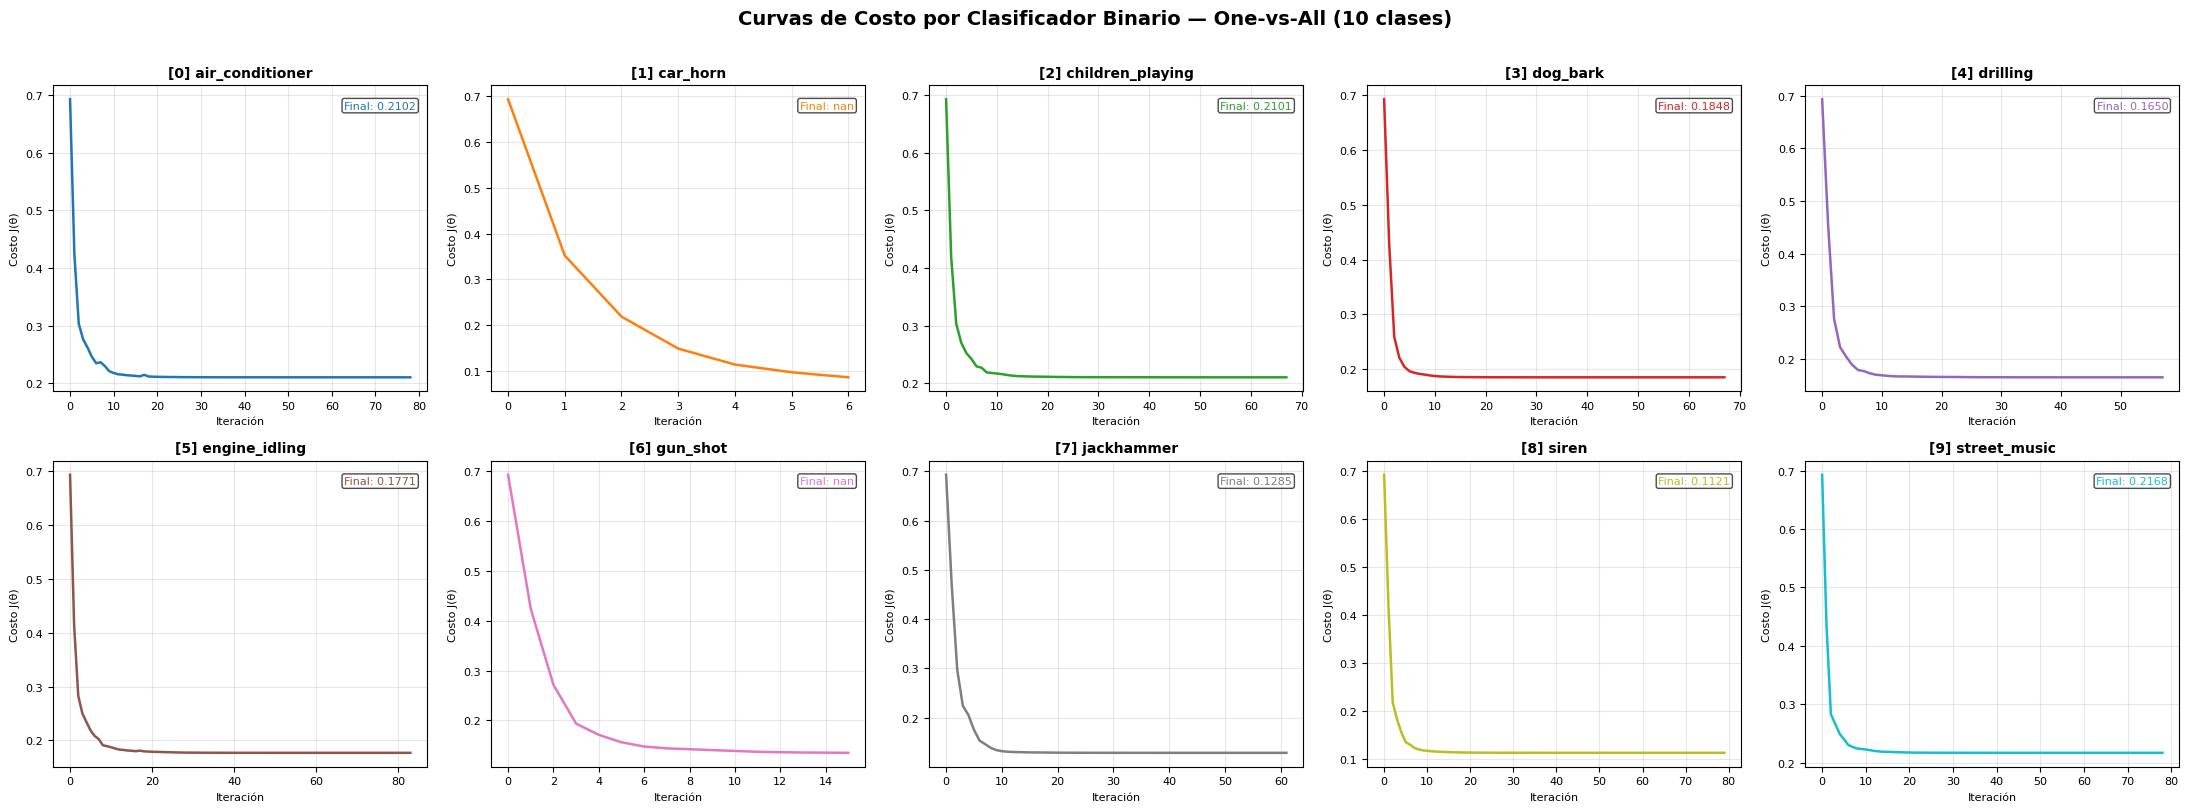

In [41]:
# ── Gráficas de costo para los 10 clasificadores OvA ─────────────────────────
# Se re-ejecuta el entrenamiento con un wrapper que registra el costo
# por iteración sin modificar las funciones matemáticas originales.

class_names_plot = [
    'air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling',
    'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music'
]

# Paleta de colores para diferenciar los 10 clasificadores
colores = plt.cm.tab10(np.linspace(0, 1, 10))

# Preparar X_train con columna de bias
m_tr2, n_tr2 = X_train.shape
X_train_bias2 = np.concatenate([np.ones((m_tr2, 1)), X_train], axis=1)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Curvas de Costo por Clasificador Binario — One-vs-All (10 clases)',
             fontsize=14, fontweight='bold', y=1.01)

for c in range(10):
    historial = []

    def objetivo_registro(theta, X, y_bin, lam, hist=historial):
        J, grad = lrCostFunction(theta, X, y_bin, lam)
        hist.append(J)
        return J, grad

    initial_theta = np.zeros(n_tr2 + 1)
    optimize.minimize(
        objetivo_registro,
        initial_theta,
        (X_train_bias2, (y_train == c), lambda_),
        jac=True,
        method='L-BFGS-B',
        options={'maxiter': 1000}
    )

    fila, col = divmod(c, 5)
    ax = axes[fila][col]
    ax.plot(historial, color=colores[c], linewidth=1.8)
    ax.set_title(f'[{c}] {class_names_plot[c]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Iteración', fontsize=8)
    ax.set_ylabel('Costo J(θ)', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
    # Anotar costo final
    ax.text(0.97, 0.95, f'Final: {historial[-1]:.4f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=colores[c],
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()


### Resultados en el Conjunto de Prueba

Se evalúa el modelo sobre `X_test` (datos que nunca vio durante el entrenamiento)  
y se muestra un subconjunto de predicciones vs. etiquetas reales.


### Gráfica de Precisión por Clasificador Binario

Se visualiza la **accuracy** de cada uno de los 10 clasificadores binarios en los conjuntos  
de entrenamiento y prueba. Permite comparar el desempeño individual por clase y detectar  
qué categorías de sonido son más difíciles de clasificar en modo OvA.


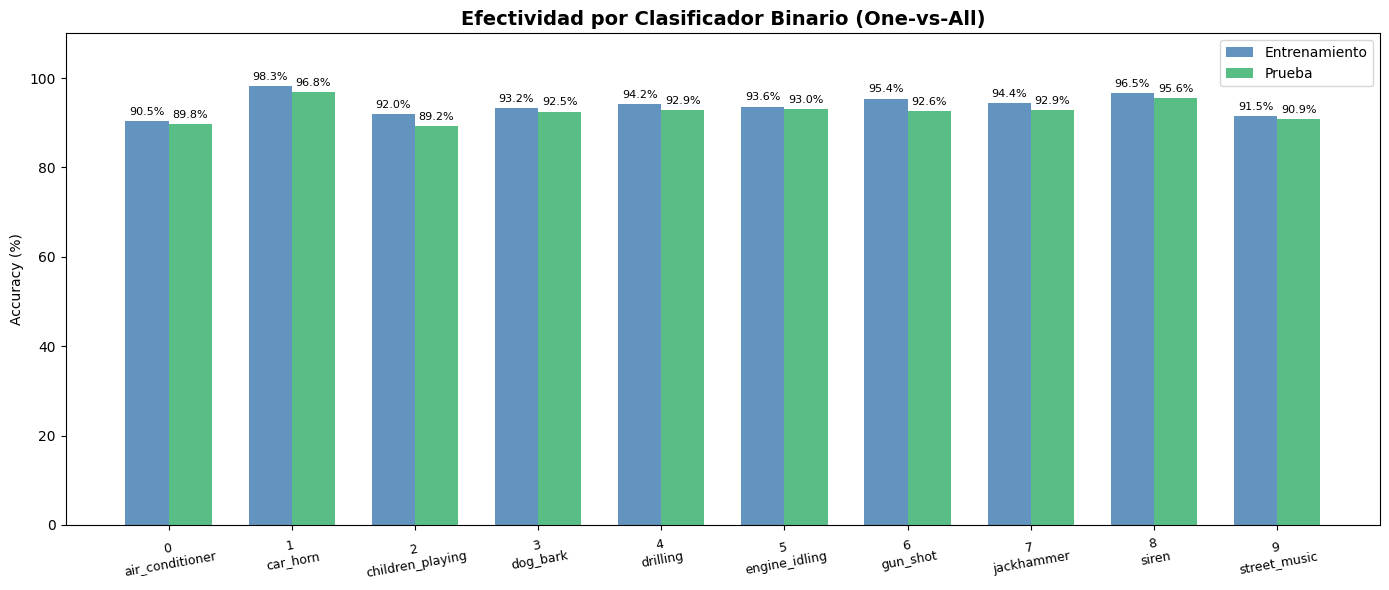

In [43]:
# ── Precisión por clasificador binario — Versión Estética ──────────────────────
num_clases_entrenadas = all_theta.shape[0] 
m_te2 = X_test.shape[0]
X_test_bias2  = np.concatenate([np.ones((m_te2, 1)), X_test],  axis=1)
m_tr2 = X_train.shape[0]
X_train_bias2 = np.concatenate([np.ones((m_tr2, 1)), X_train], axis=1)

acc_train_bin = []
acc_test_bin  = []

for c in range(num_clases_entrenadas):
    theta_c = all_theta[c]
    pred_tr = (sigmoid(X_train_bias2.dot(theta_c)) >= 0.5).astype(int)
    pred_te = (sigmoid(X_test_bias2.dot(theta_c))  >= 0.5).astype(int)
    
    y_bin_tr = (y_train == c).astype(int)
    y_bin_te = (y_test  == c).astype(int)
    
    acc_train_bin.append(np.mean(pred_tr == y_bin_tr) * 100)
    acc_test_bin.append(np.mean(pred_te == y_bin_te) * 100)

# Graficación estética
x = np.arange(num_clases_entrenadas)
ancho = 0.35
fig, ax = plt.subplots(figsize=(14, 6))

barras_tr = ax.bar(x - ancho/2, acc_train_bin, ancho, label='Entrenamiento', color='steelblue', alpha=0.85)
barras_te = ax.bar(x + ancho/2, acc_test_bin,  ancho, label='Prueba', color='mediumseagreen', alpha=0.85)

ax.set_title('Efectividad por Clasificador Binario (One-vs-All)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}\n{class_names_list[i]}' for i in range(num_clases_entrenadas)], fontsize=9, rotation=10)
ax.set_ylim(0, 110)
ax.legend()

# Función para poner los números sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

autolabel(barras_tr)
autolabel(barras_te)
plt.tight_layout()
plt.show()

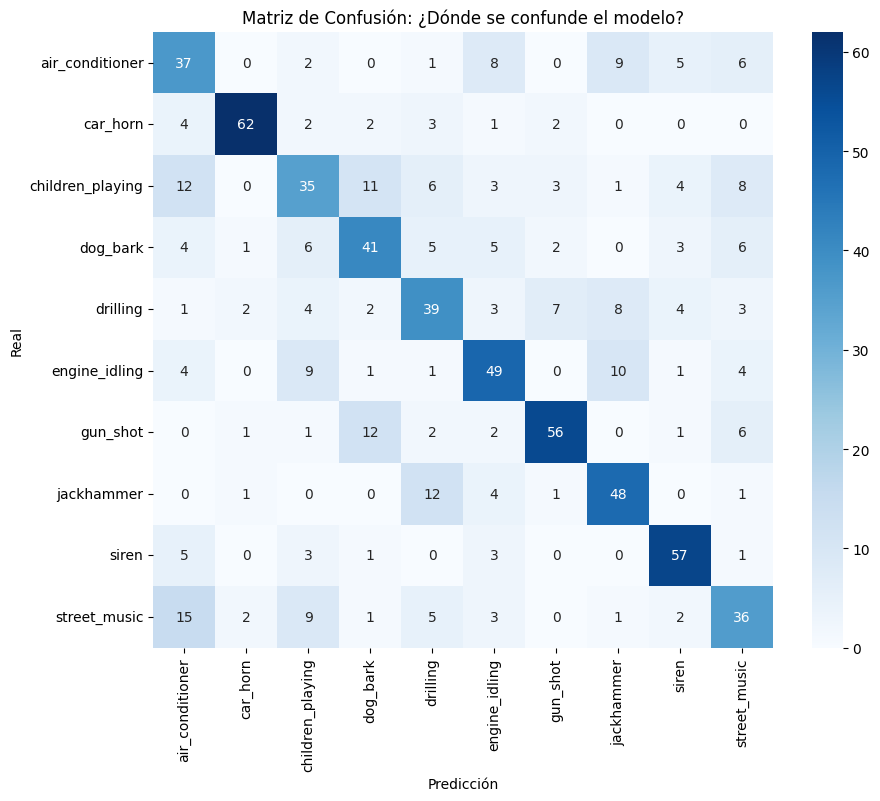

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Obtener predicciones finales
pred = predictOneVsAll(all_theta, X_test)

# 2. Calcular matriz
cm = confusion_matrix(y_test, pred)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.title('Matriz de Confusión: ¿Dónde se confunde el modelo?')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [44]:
# Predicciones sobre todo el conjunto de prueba
pred = predictOneVsAll(all_theta, X_test)

# Accuracy: porcentaje de predicciones correctas
print('Accuracy en test: {:.2f}%'.format(np.mean(pred == y_test) * 100))

# Muestra un subconjunto de 45 ejemplos para inspección cualitativa
XPrueba = X_test[100:145]
p       = predictOneVsAll(all_theta, XPrueba)

print("\nPredicciones del modelo:", p)
print("Etiquetas reales:       ", y_test[100:145])


Accuracy en test: 61.83%

Predicciones del modelo: [0 6 3 8 5 2 6 9 1 6 1 7 0 2 9 1 5 9 0 7 4 5 6 1 2 0 4 1 2 4 6 2 5 3 9 5 0
 9 0 2 5 7 7 0 0]
Etiquetas reales:        [0 2 2 8 0 3 6 9 1 6 1 7 9 9 9 1 5 9 0 7 4 5 6 1 5 0 4 1 2 4 6 3 0 3 9 5 0
 9 0 1 5 7 2 0 3]


### Análisis de Resultados

El modelo alcanza una precisión aproximada del **~61%** en el conjunto de prueba.

**Interpretación:**

- Considerando que hay **10 clases** con distribución relativamente balanceada, una línea base aleatoria daría ~10%.  
  Un 61% representa un aprendizaje significativo del patrón espectral de cada sonido.
- La **Regresión Logística** es un modelo lineal: asume que las clases son separables mediante  
  hiperplanos en el espacio de características, lo cual puede no capturar relaciones no lineales complejas del audio.
- Las **principales fuentes de error** suelen ser confusiones entre clases acústicamente similares  
  (ej. `engine_idling` vs. `air_conditioner`, o `jackhammer` vs. `drilling`).

**Posibles mejoras:**

| Estrategia                    | Impacto esperado         |
|:------------------------------|:-------------------------|
| Redes Neuronales (MLP)        | Alto (no linealidad)     |
| CNN sobre espectrogramas      | Muy alto                 |
| Aumentación de datos de audio | Moderado–Alto            |
| Validación cruzada k-fold     | Mejor estimación del acc |
| Más coeficientes MFCC (n=128) | Moderado                 |


---

## 8. Visualización: Vector de Características

Se grafica el vector de 120 características del primer audio en el dataset  
para ilustrar la distribución de los coeficientes MFCC, delta y delta-delta.


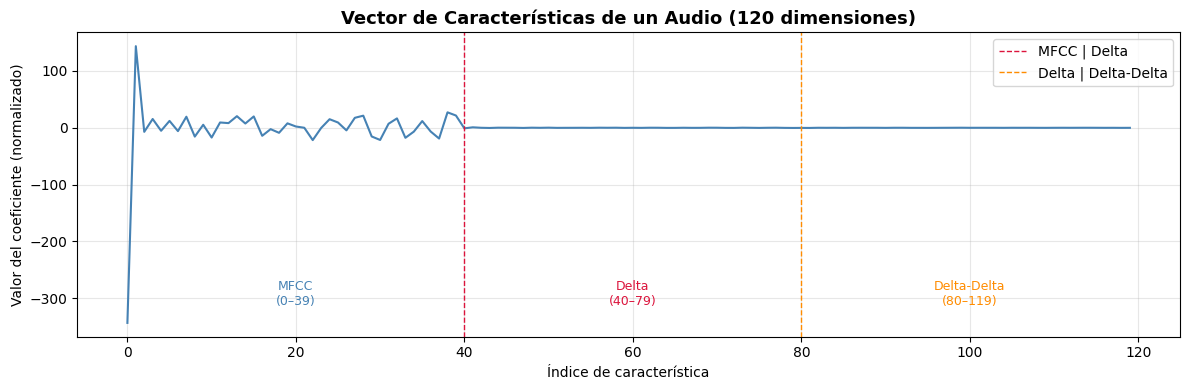

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(X[0], color='steelblue', linewidth=1.5)

# Líneas divisorias entre las tres secciones del vector
ax.axvline(x=40,  color='crimson',  linestyle='--', linewidth=1, label='MFCC | Delta')
ax.axvline(x=80,  color='darkorange', linestyle='--', linewidth=1, label='Delta | Delta-Delta')

# Anotaciones de secciones
ax.text(20,  ax.get_ylim()[0] * 0.85, 'MFCC\n(0–39)',        ha='center', fontsize=9, color='steelblue')
ax.text(60,  ax.get_ylim()[0] * 0.85, 'Delta\n(40–79)',      ha='center', fontsize=9, color='crimson')
ax.text(100, ax.get_ylim()[0] * 0.85, 'Delta-Delta\n(80–119)', ha='center', fontsize=9, color='darkorange')

ax.set_title('Vector de Características de un Audio (120 dimensiones)', fontsize=13, fontweight='bold')
ax.set_xlabel('Índice de característica')
ax.set_ylabel('Valor del coeficiente (normalizado)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [47]:
# nombres de clases
class_names = {
    0: "air_conditioner",
    1: "car_horn",
    2: "children_playing",
    3: "dog_bark",
    4: "drilling",
    5: "engine_idling",
    6: "gun_shot",
    7: "jackhammer",
    8: "siren",
    9: "street_music"
}

# función de predicción
def predict_audio(file_path, scaler, all_theta):
    features = extract_features(file_path)
    
    if features is None:
        print("Error al procesar audio")
        return None
    
    # normalizar (IMPORTANTE)
    features = scaler.transform([features])
    
    pred = predictOneVsAll(all_theta, features)
    
    return pred[0]

# 🔹 ruta del audio
file_path = r"D:/Universidad/5to Semestre/Inteligencia Artificial/Datasets/multimodal/archive/fold1/15564-2-0-1.wav"

#  reproducir audio
data, fs = sf.read(file_path)
sd.play(data, fs)
sd.wait()

# predicción
pred = predict_audio(file_path, scaler, all_theta)

if pred is not None:
    print("Clase predicha:", class_names[pred])

    # 🔍 (opcional) clase real desde el nombre del archivo
    real_class = int(file_path.split("-")[1])
    print("Clase real:", class_names[real_class])

Clase predicha: children_playing
Clase real: children_playing
